In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



In [71]:
actions = ['add_atom_action', 'change_atom_action', 'delete_below_atom_action', 
           'insert_between_atoms_action', 'move_atom_action', 'move_towards_atom_action', 
           'remove_atom_action', 'rotate_around_atom_action','swap_atoms_action']

models = ['deepseek_chat', 'gemini_2_5_pro', 'llama3_70b','qwen3_32B', 'qwen3_14B', 'qwen3_8B', 'qwen3_4B', 'o3', 'o4_mini']

model_name = models[1]
action_name = actions[3]

result_folder = f'../../results/AtomWorld/{model_name}/{action_name}'

result_correct = f'{result_folder}/{action_name}_evaluation_results.csv'
result_wrong = f'{result_folder}/{action_name}_evaluation_wrongs.csv'

result_correct = pd.read_csv(result_correct)
result_wrong = pd.read_csv(result_wrong)


In [72]:
from utils.dataloader import load_cif_file_from_string


result_correct["num_site"] = result_correct["input_cif"].apply(
    lambda cif: load_cif_file_from_string(cif).num_sites
)

result_wrong["num_site"] = result_wrong["input_cif"].apply(
    lambda cif: load_cif_file_from_string(cif).num_sites
)

D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomW

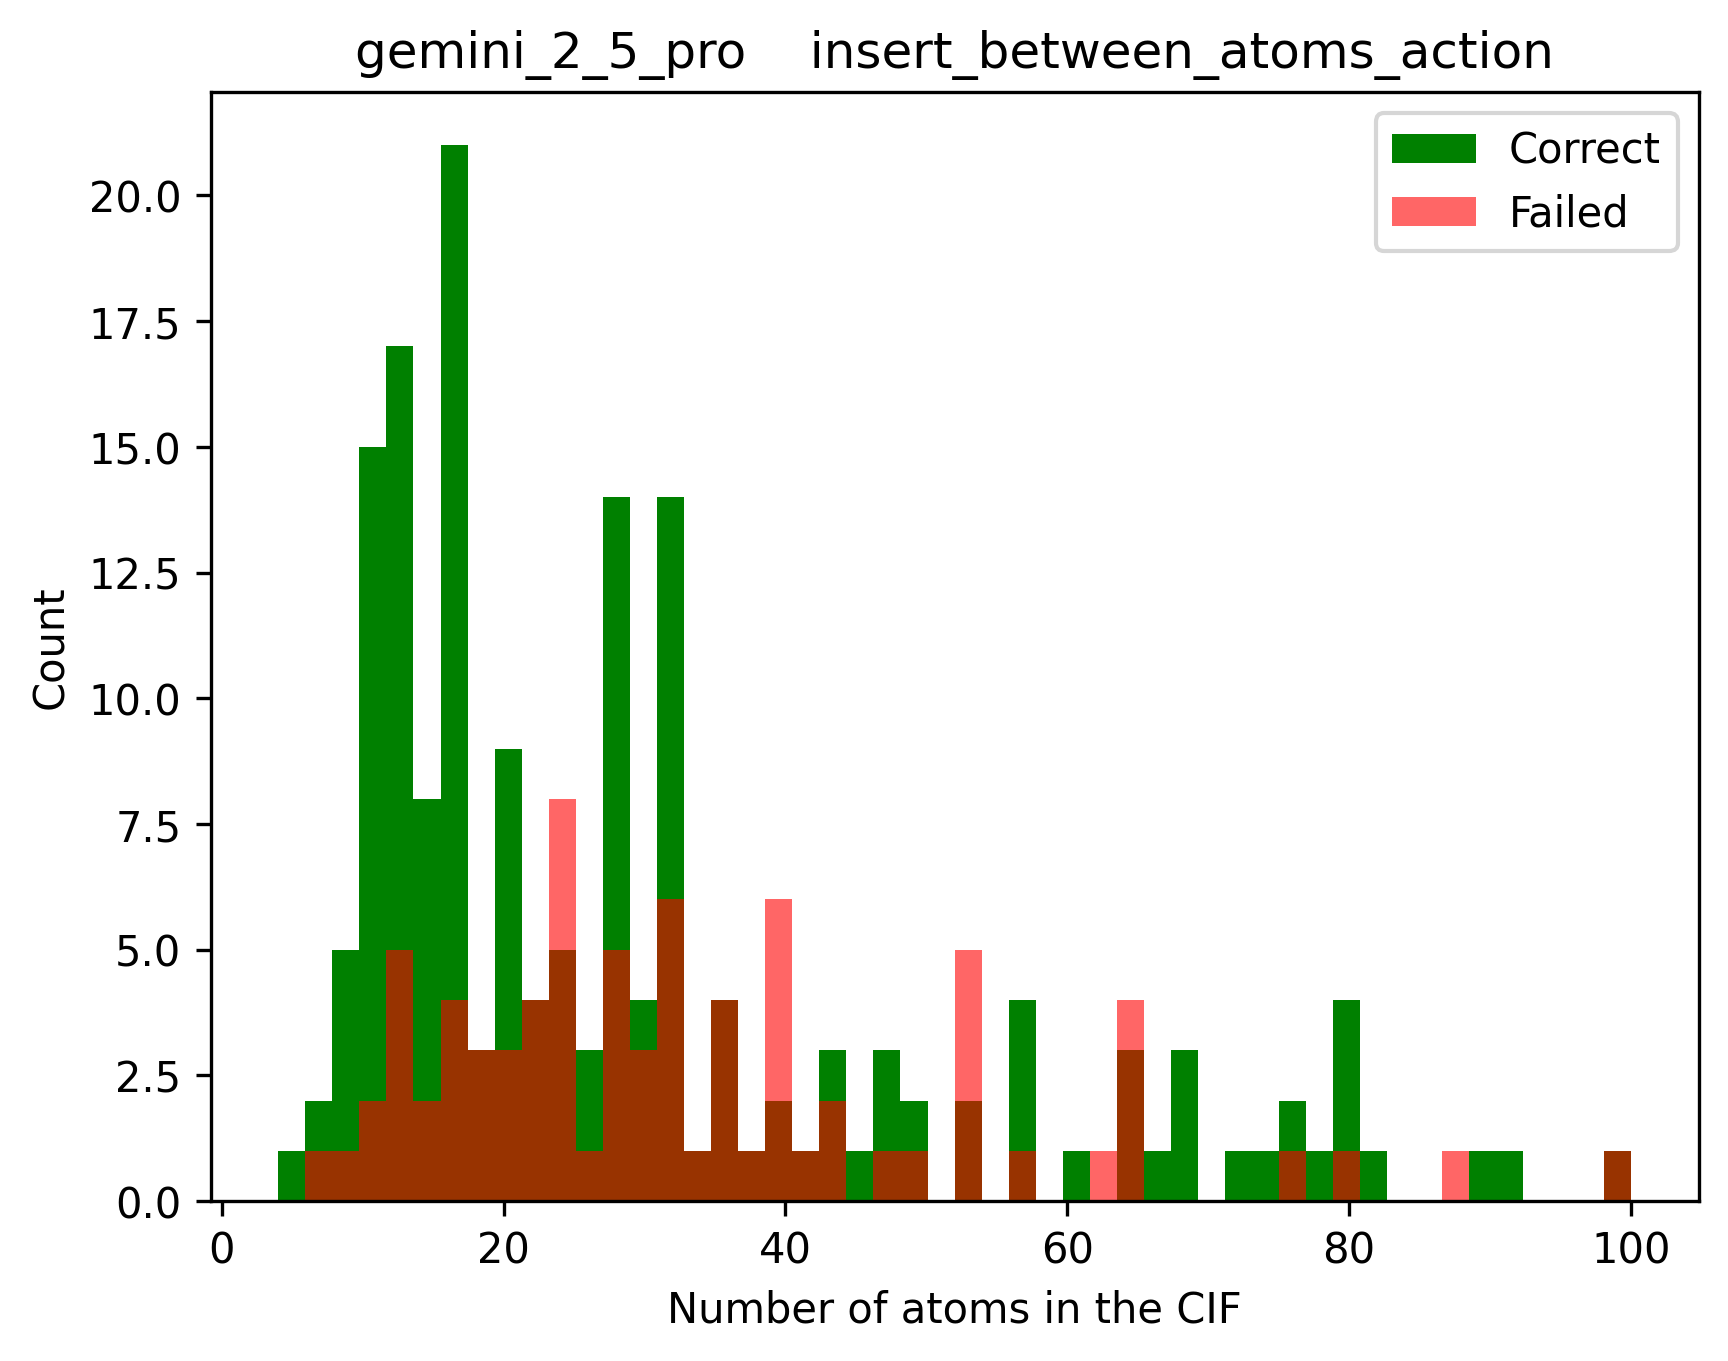

In [ ]:
all_data = list(result_correct["num_site"]) + list(result_wrong["num_site"])
bins = np.linspace(min(all_data), max(all_data), 51)  # 50 bins

plt.figure(dpi=120)

plt.hist(result_correct["num_site"], bins=bins, color="green", alpha=1.0, label="Correct")
plt.hist(result_wrong["num_site"], bins=bins, color="red", alpha=0.6, label="Failed")

plt.xlabel("Number of atoms in the CIF")
plt.ylabel("Count")
plt.title(f"{model_name}    {action_name}")
plt.legend()
plt.savefig(f"{model_name}-{action_name}.png", dpi=300)

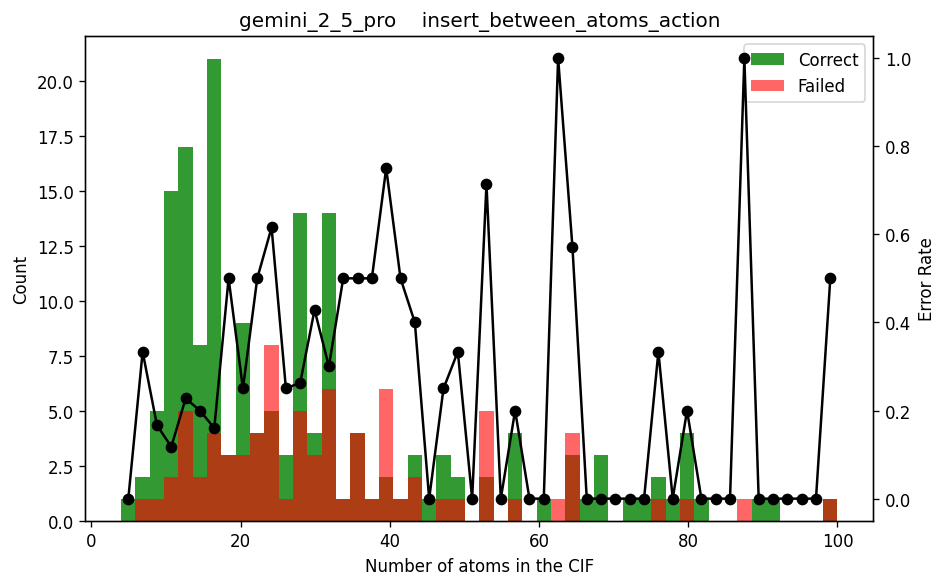

In [74]:
all_data = list(result_correct["num_site"]) + list(result_wrong["num_site"])
bins = np.linspace(min(all_data), max(all_data), 51)  # 50 bins

# Histogram counts
counts_correct, _ = np.histogram(result_correct["num_site"], bins=bins)
counts_wrong, _   = np.histogram(result_wrong["num_site"], bins=bins)

# Error rate per bin (avoid division by zero)
error_rate = np.zeros_like(counts_wrong, dtype=float)
mask = (counts_correct + counts_wrong) > 0
error_rate[mask] = counts_wrong[mask] / (counts_correct[mask] + counts_wrong[mask])

# Bin centers
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# --- Plot histogram ---
plt.figure(figsize=(8, 5), dpi=120)
plt.hist(result_correct["num_site"], bins=bins, color="green", alpha=0.8, label="Correct")
plt.hist(result_wrong["num_site"], bins=bins, color="red", alpha=0.6, label="Failed")

plt.xlabel("Number of atoms in the CIF")
plt.ylabel("Count")
plt.title(f"{model_name}    {action_name}")
plt.legend()

# --- Plot error rate (second y-axis) ---
ax2 = plt.gca().twinx()
ax2.plot(bin_centers, error_rate, color="black", marker="o", linestyle="-", label="Error Rate")
ax2.set_ylabel("Error Rate")

plt.tight_layout()
plt.savefig(f"{model_name}-{action_name}.png", dpi=300)

D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\Atom

[Errno 2] No such file or directory: '../../results/AtomWorld/deepseek_chat/change_atom_action\\change_atom_action_evaluation_wrongs.csv'
No columns to parse from file


D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomW

[Errno 2] No such file or directory: '../../results/AtomWorld/gemini_2_5_pro/change_atom_action\\20250918_193514\\change_atom_action_evaluation_results.csv'
[Errno 2] No such file or directory: '../../results/AtomWorld/gemini_2_5_pro/delete_below_atom_action\\20250918_193515\\delete_below_atom_action_evaluation_results.csv'


D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomW

...

[Errno 2] No such file or directory: '../../results/AtomWorld/o4_mini/change_atom_action\\20250918_193144\\change_atom_action_evaluation_results.csv'
[Errno 2] No such file or directory: '../../results/AtomWorld/o4_mini/delete_below_atom_action\\20250918_193503\\delete_below_atom_action_evaluation_results.csv'


D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomW

[Errno 2] No such file or directory: '../../results/AtomWorld/o4_mini/remove_atom_action\\20250918_193500\\remove_atom_action_evaluation_results.csv'


D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\AtomWorld\src\utils\dataloader.py:32: UserWarning: Issues encountered while parsing CIF: 20 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  structures = parser.parse_structures(primitive=primitive)
D:\Codes\Atom

[Errno 2] No such file or directory: '../../results/AtomWorld/o4_mini/swap_atoms_action\\20250918_193500\\swap_atoms_action_evaluation_results.csv'


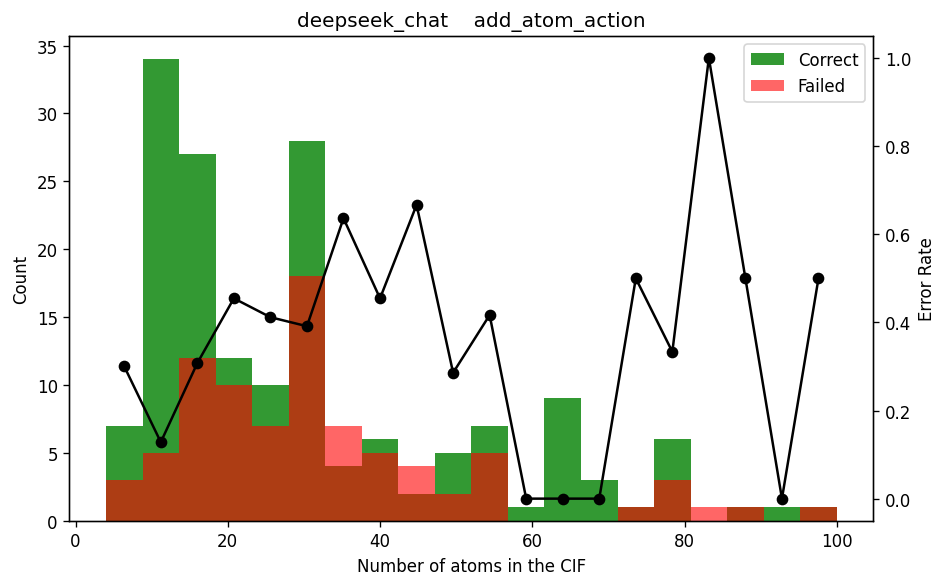

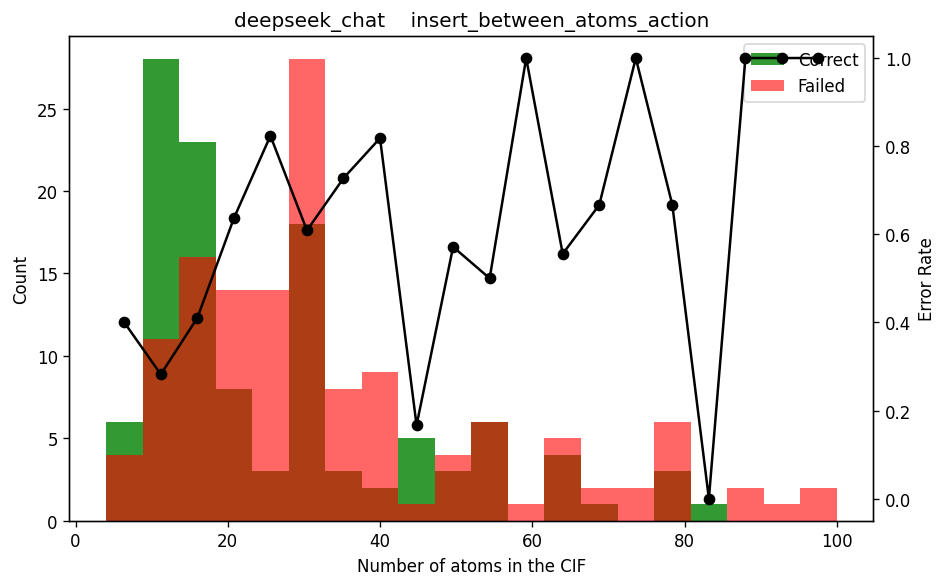

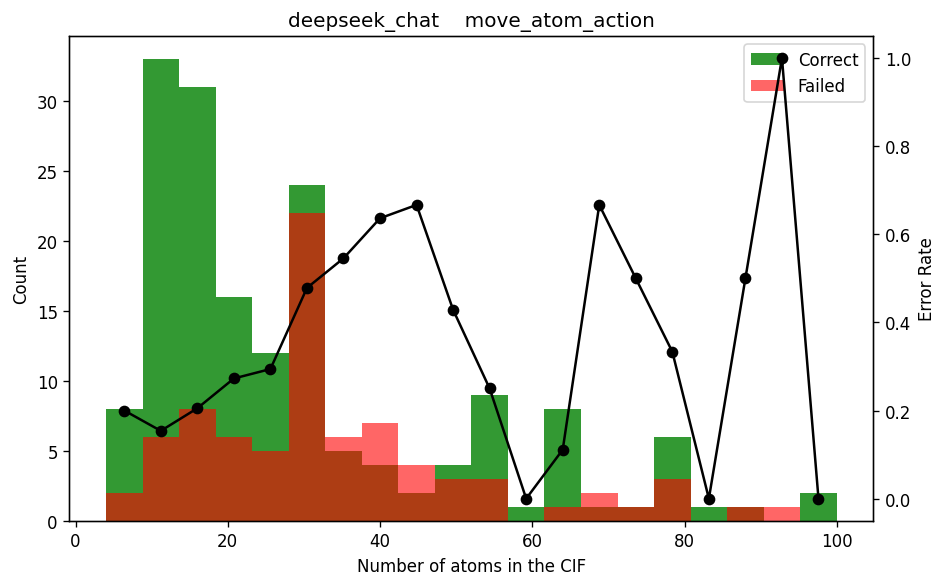

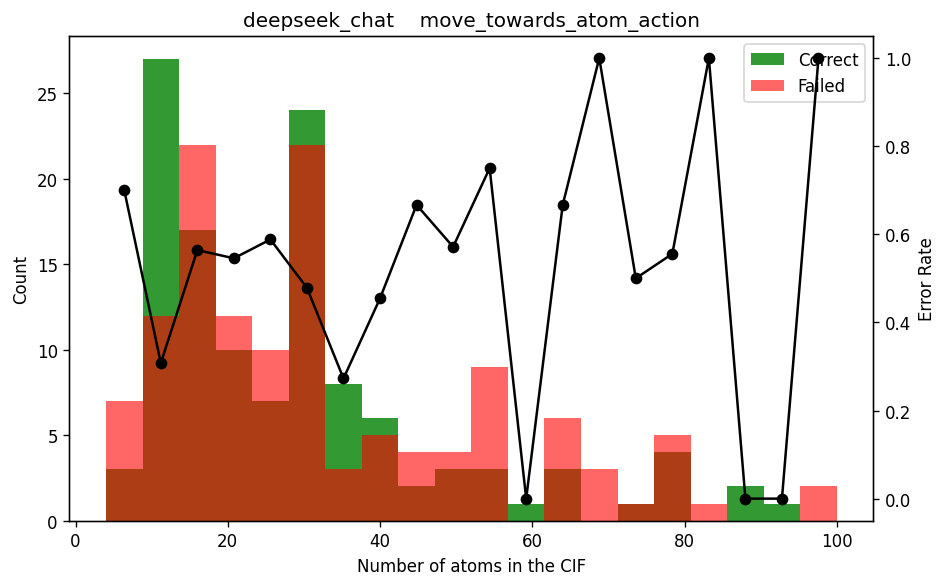

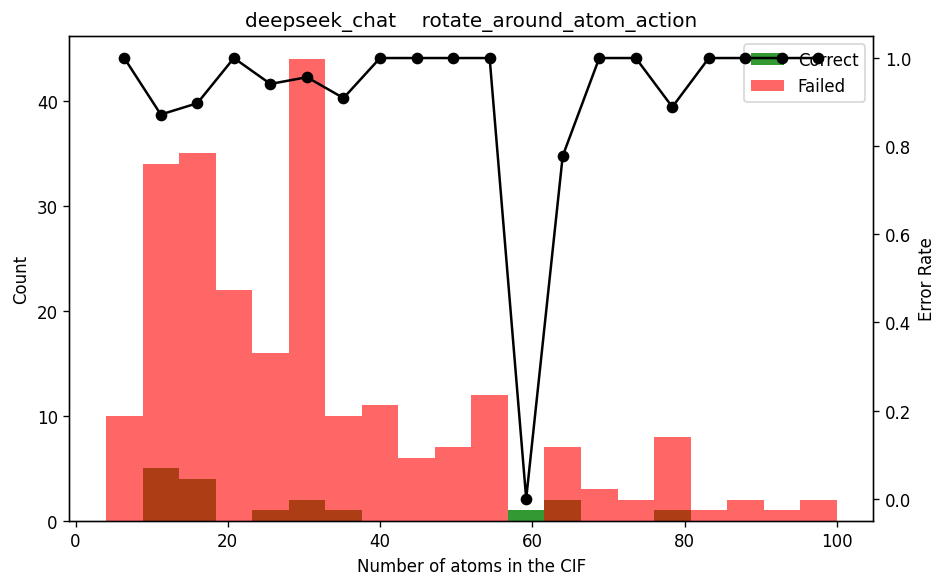

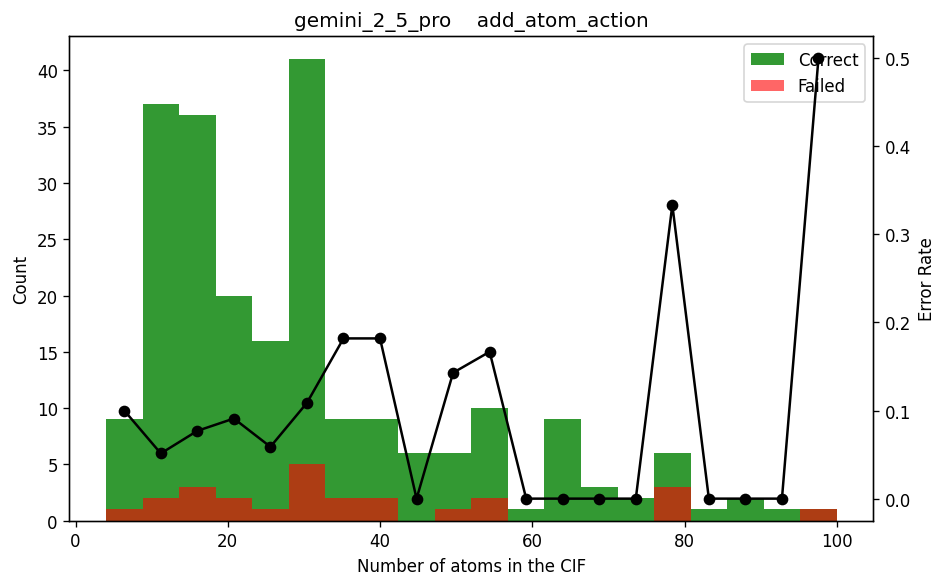

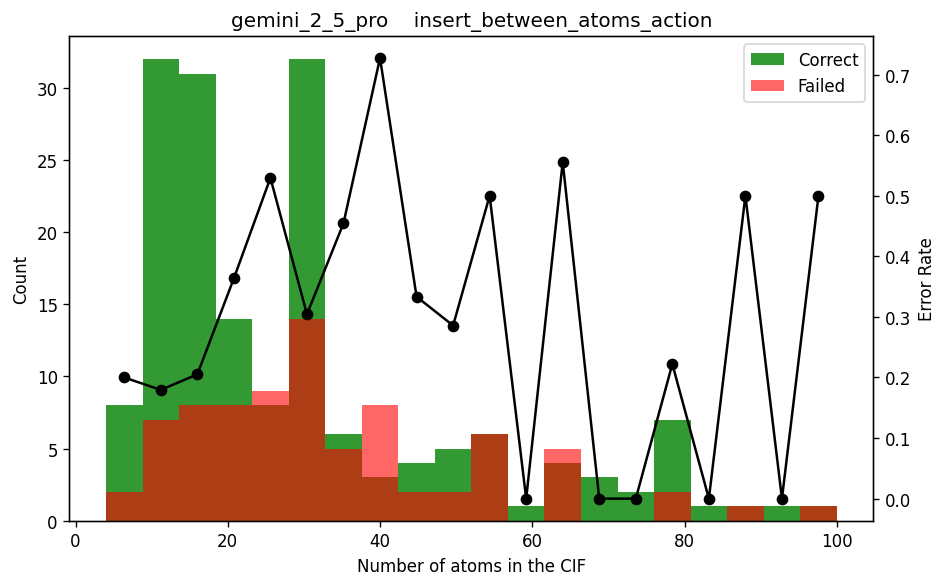

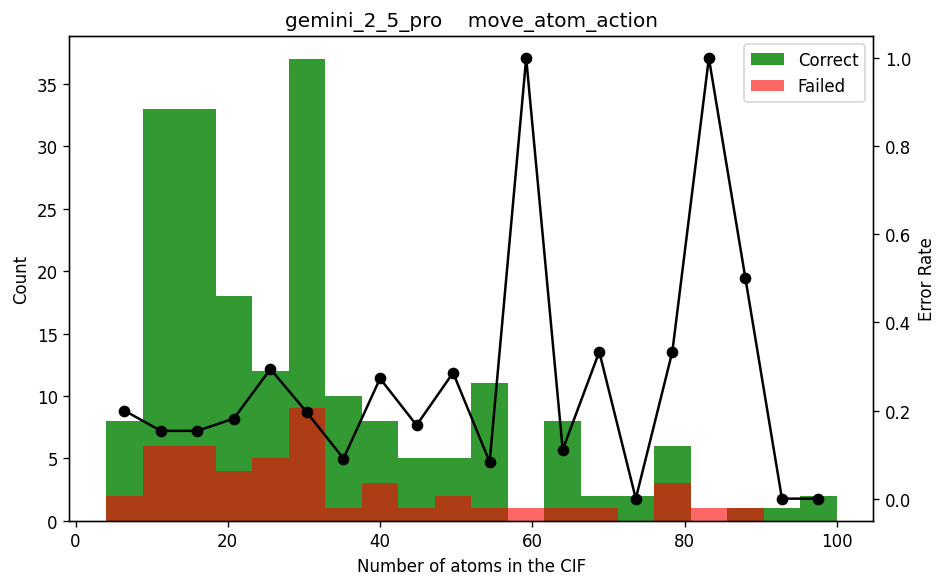

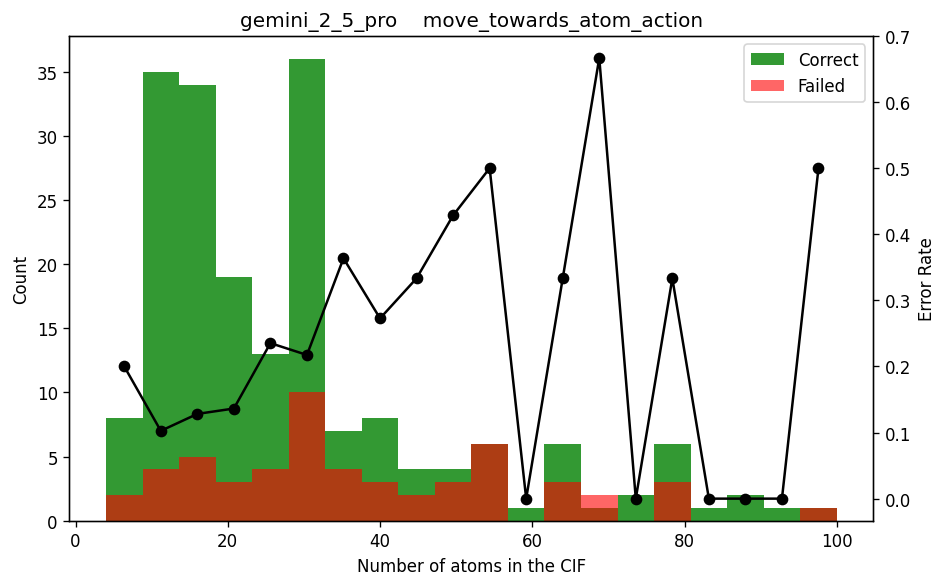

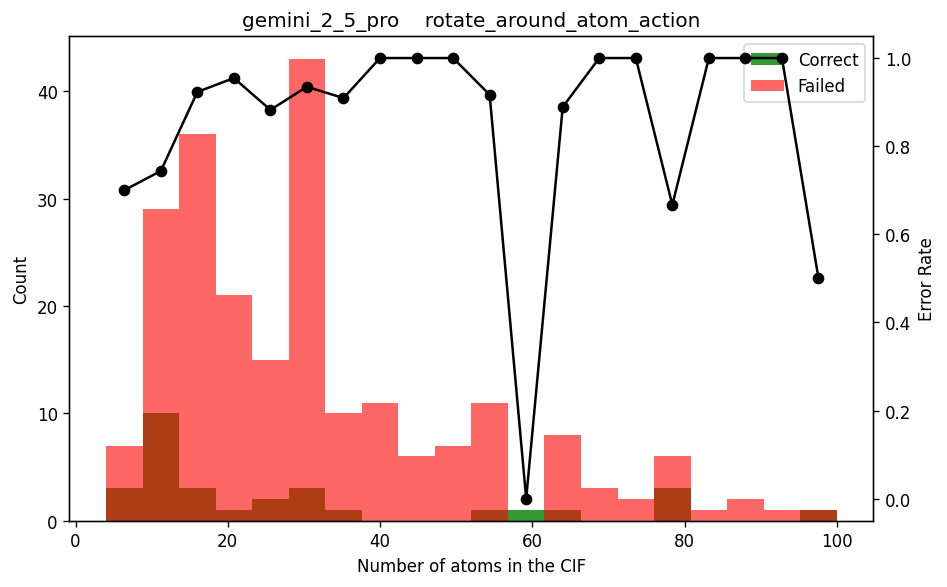

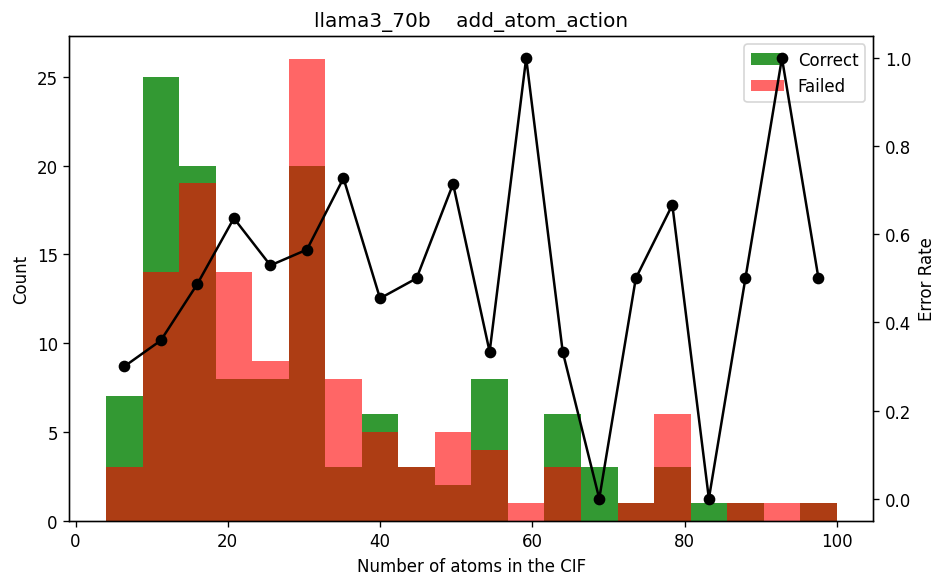

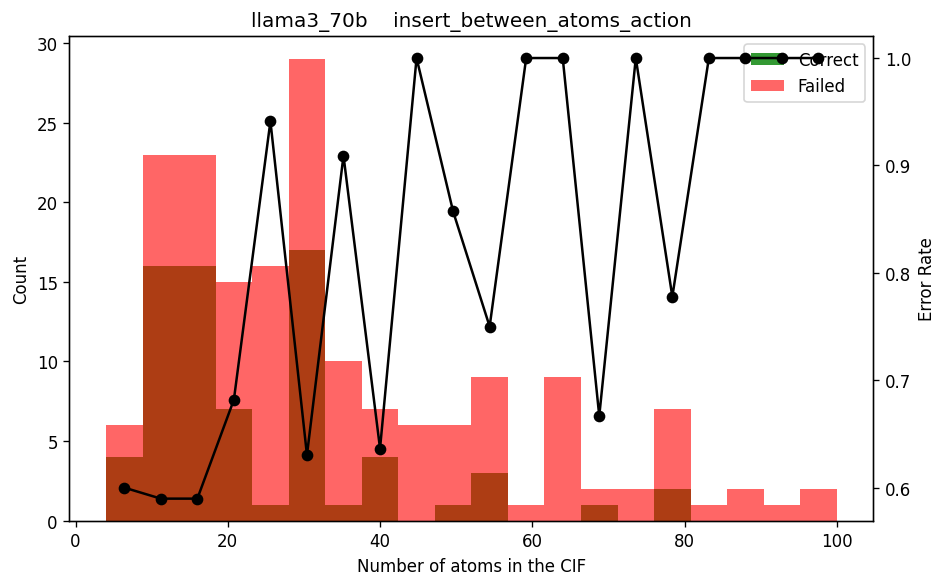

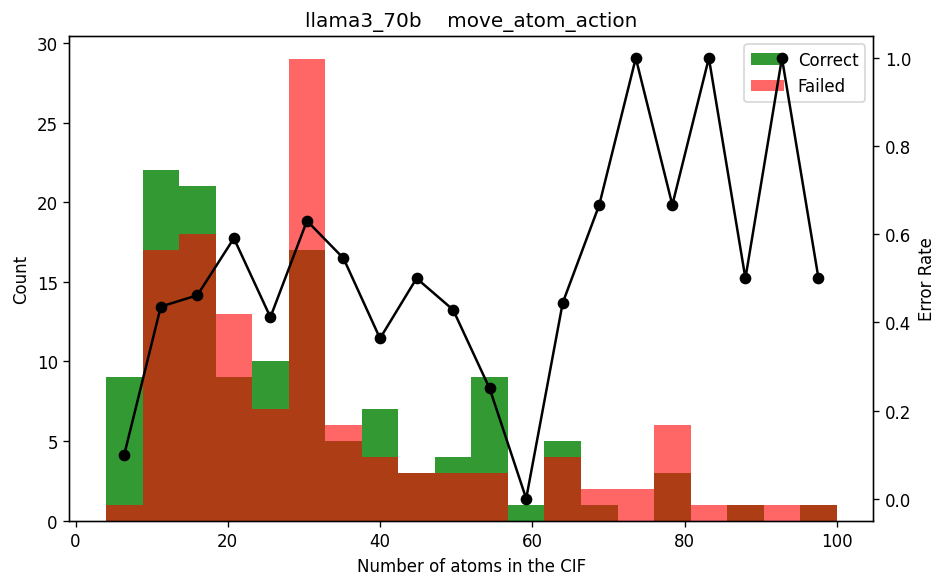

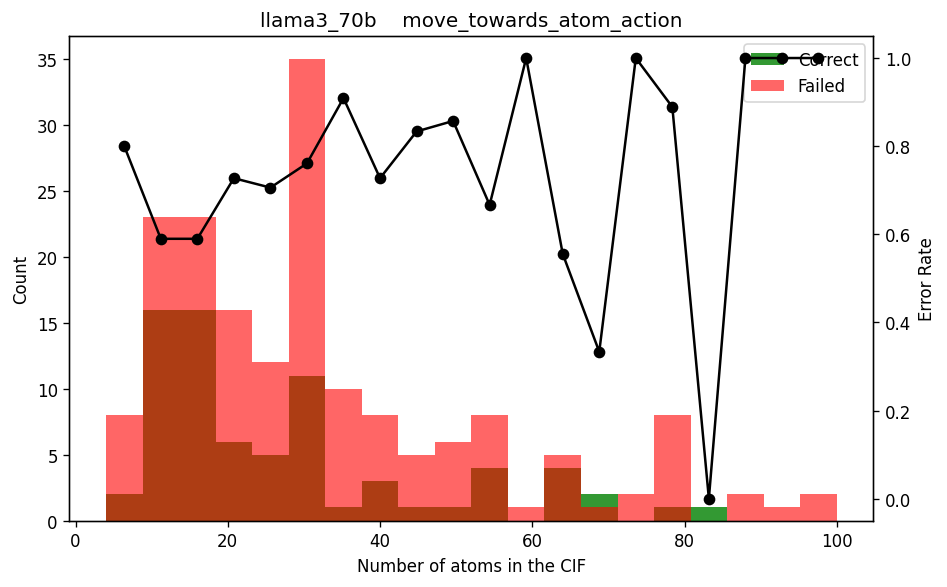

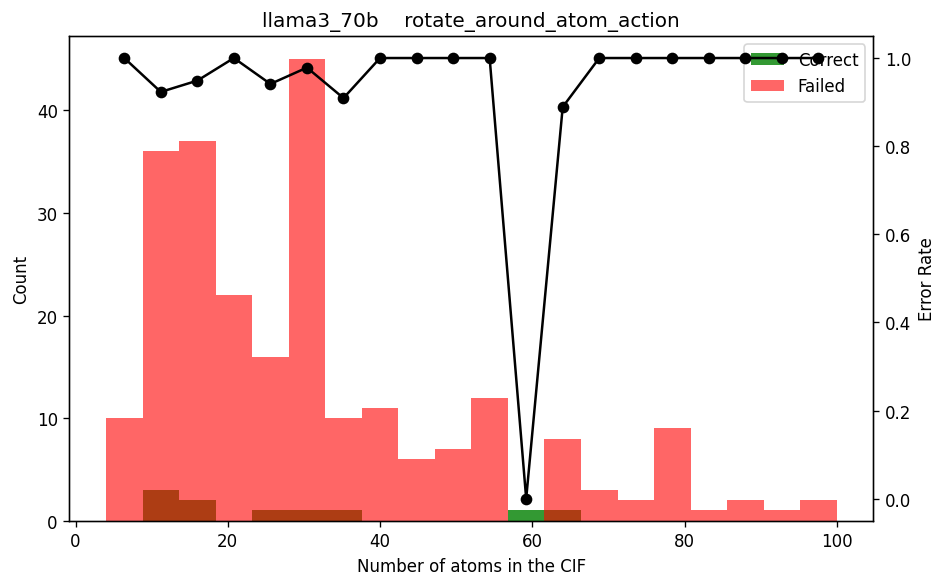

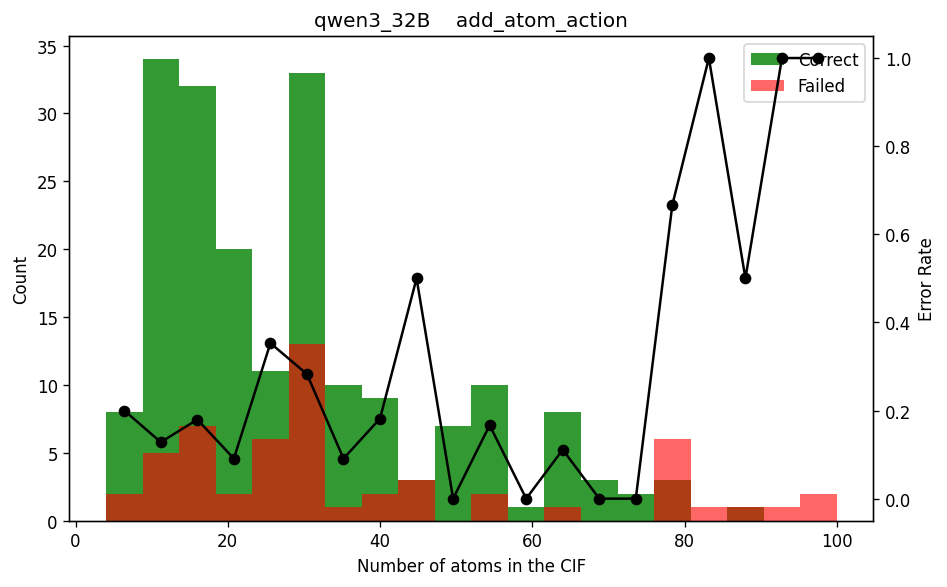

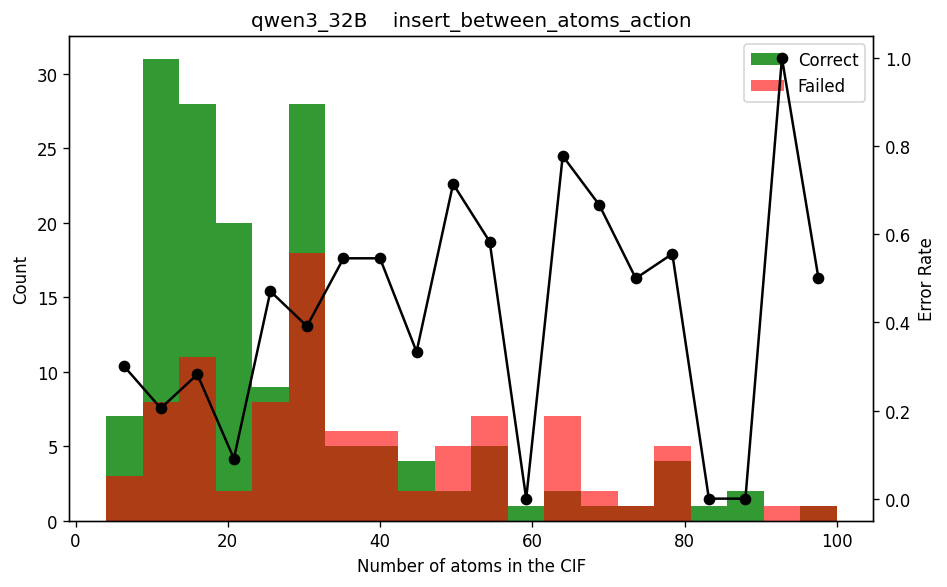

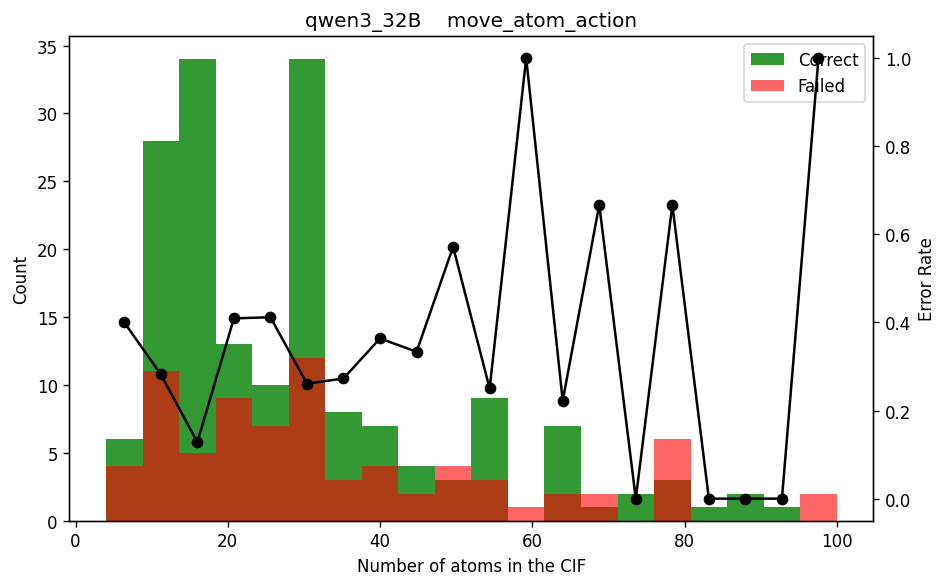

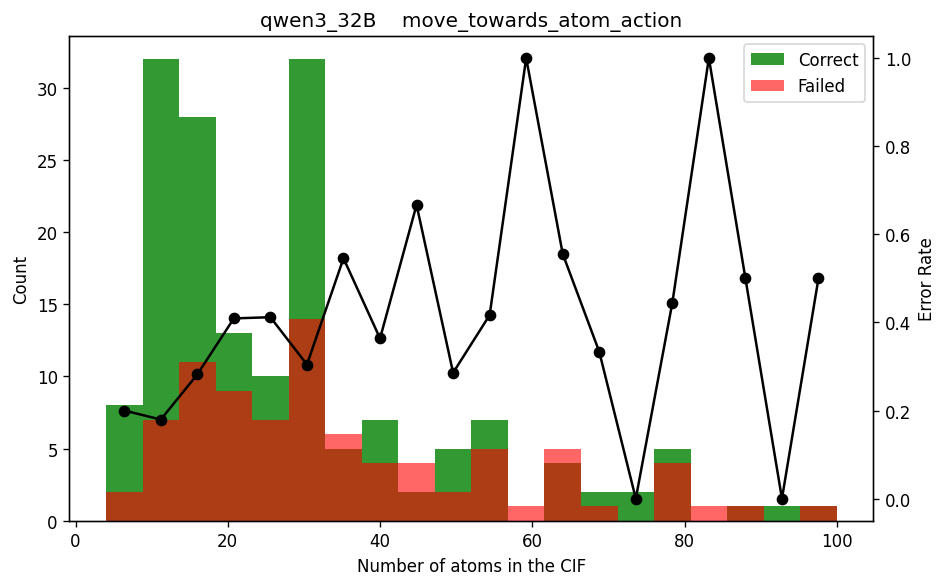

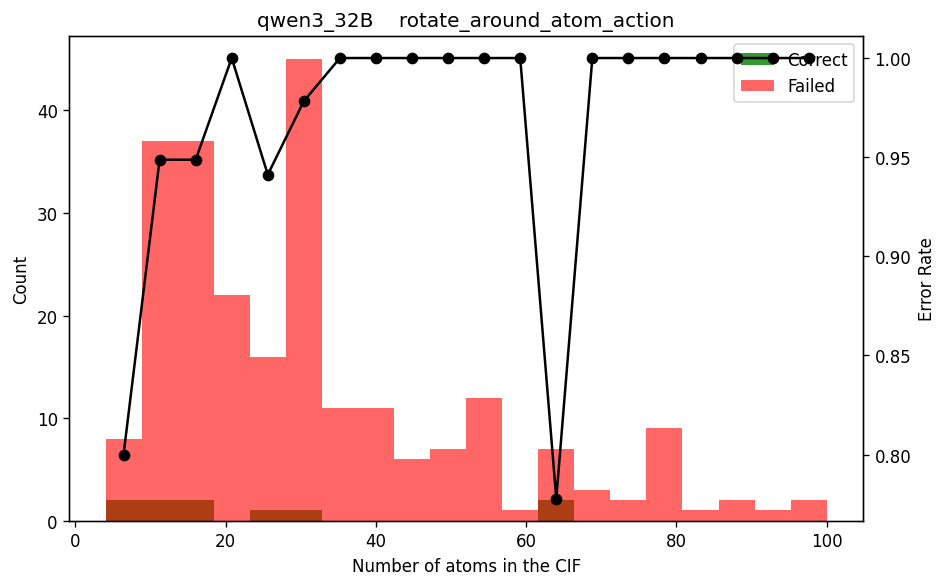

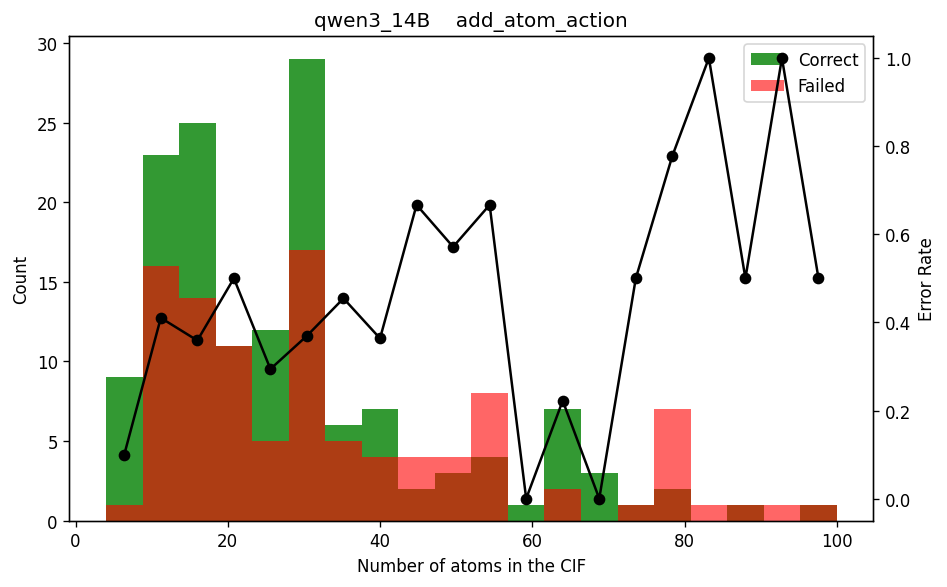

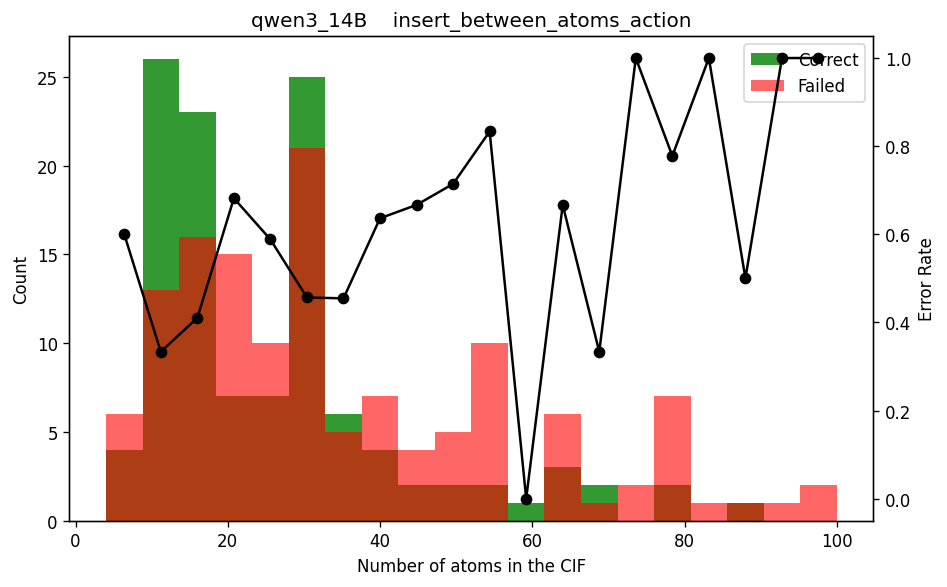

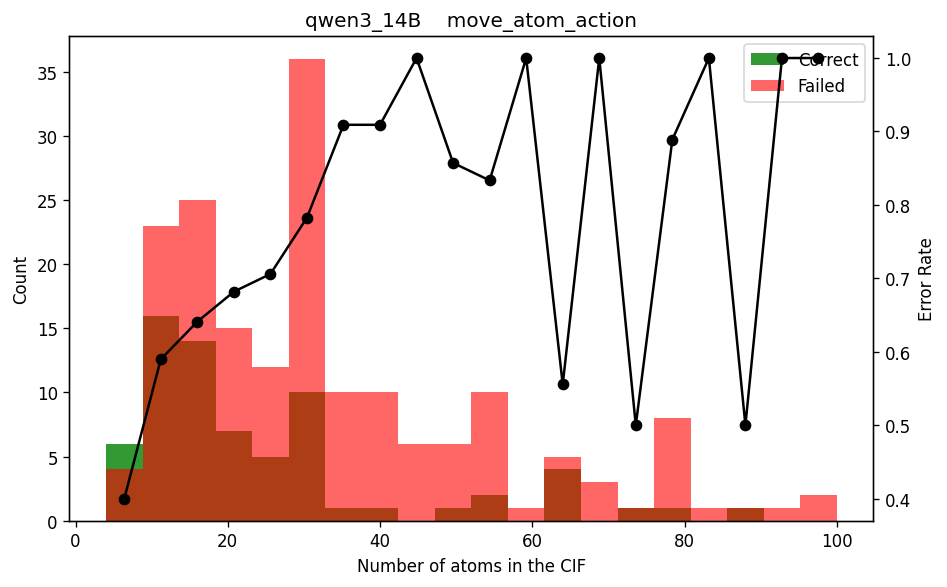

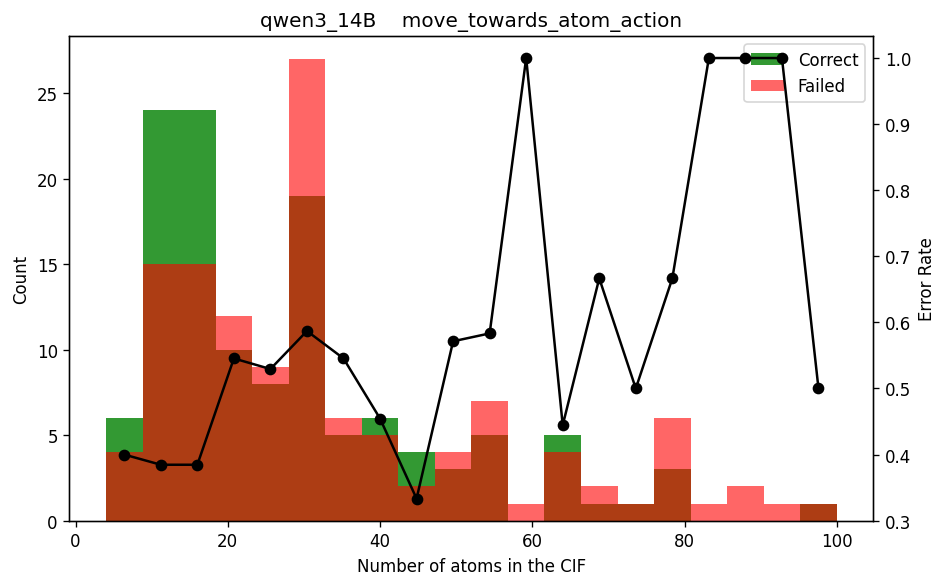

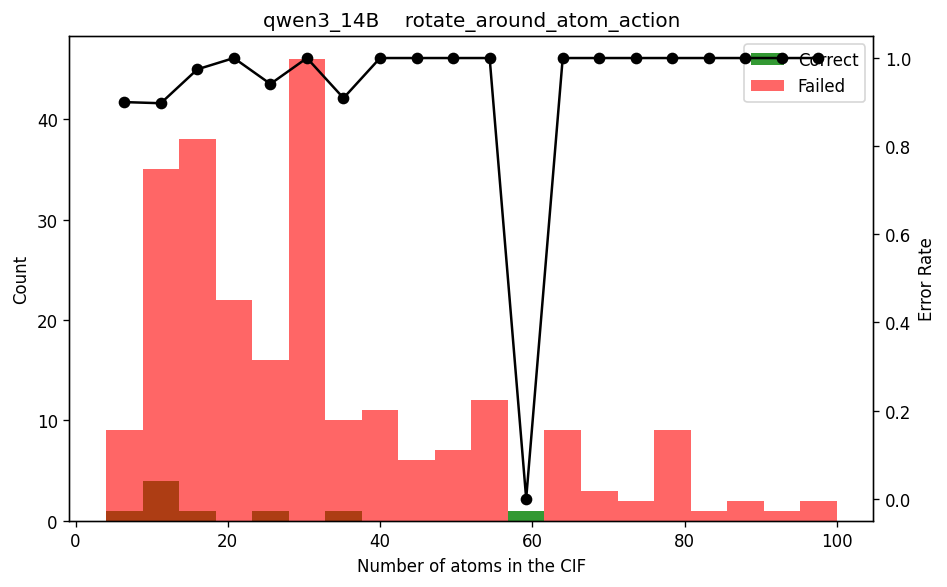

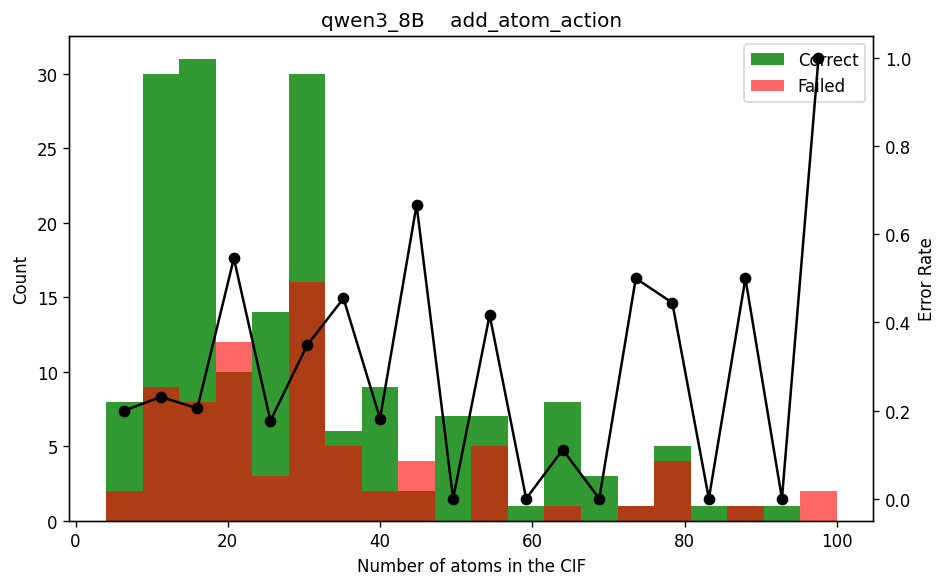

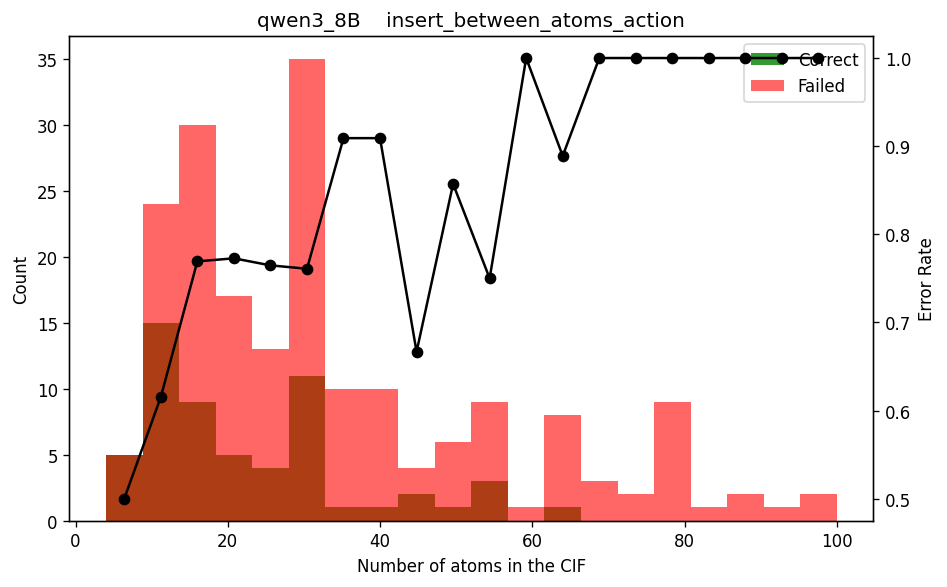

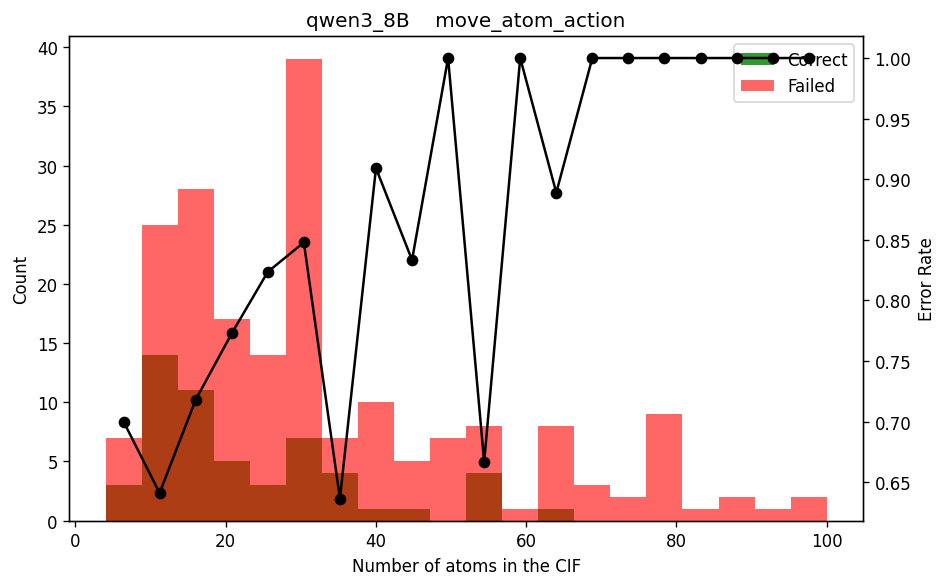

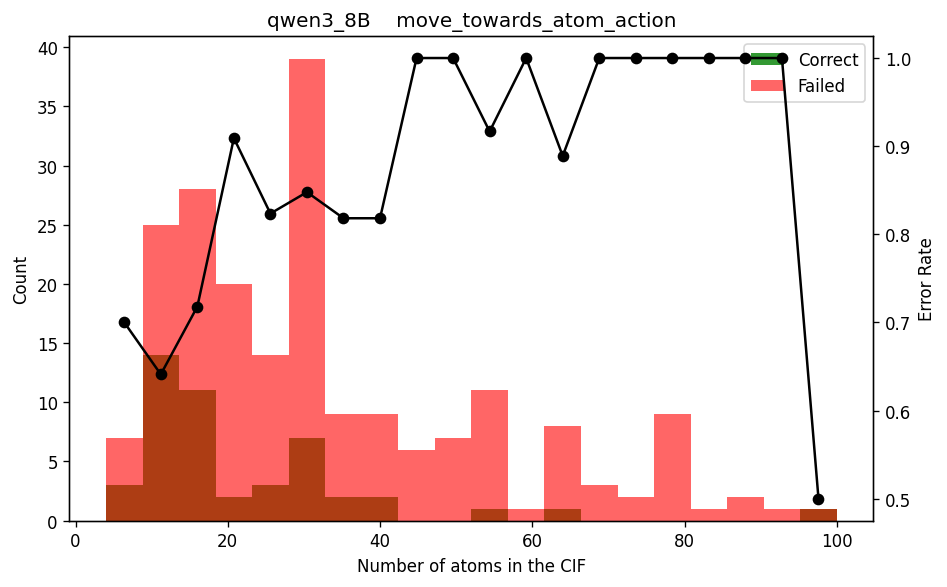

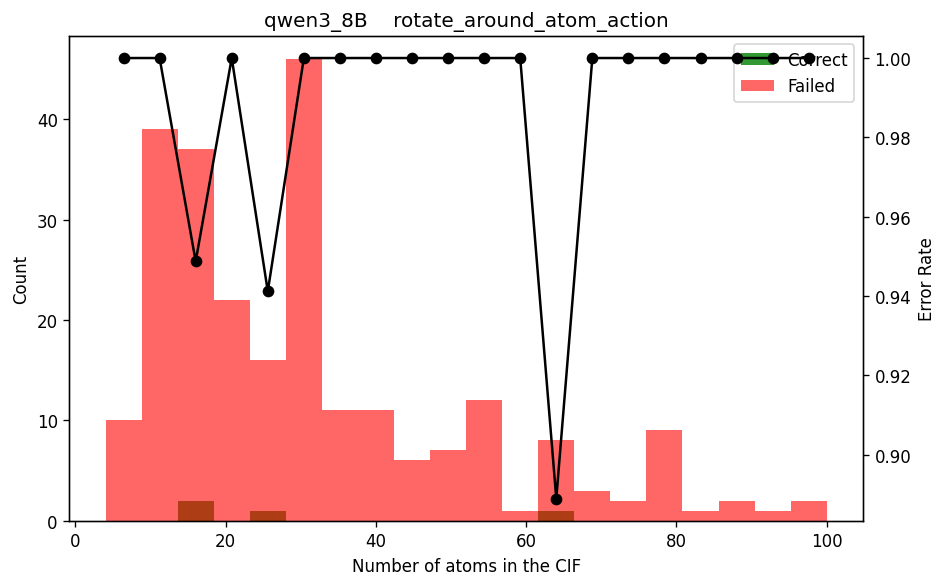

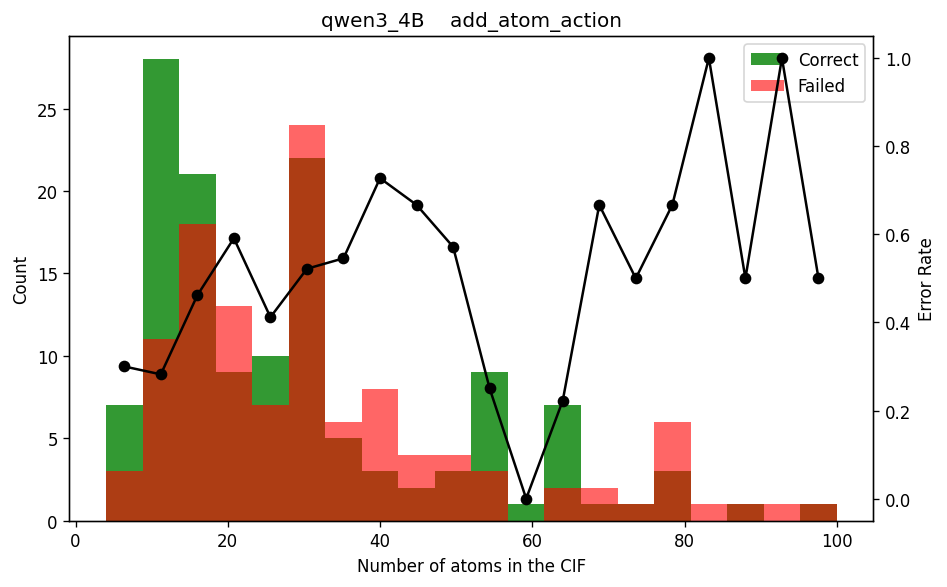

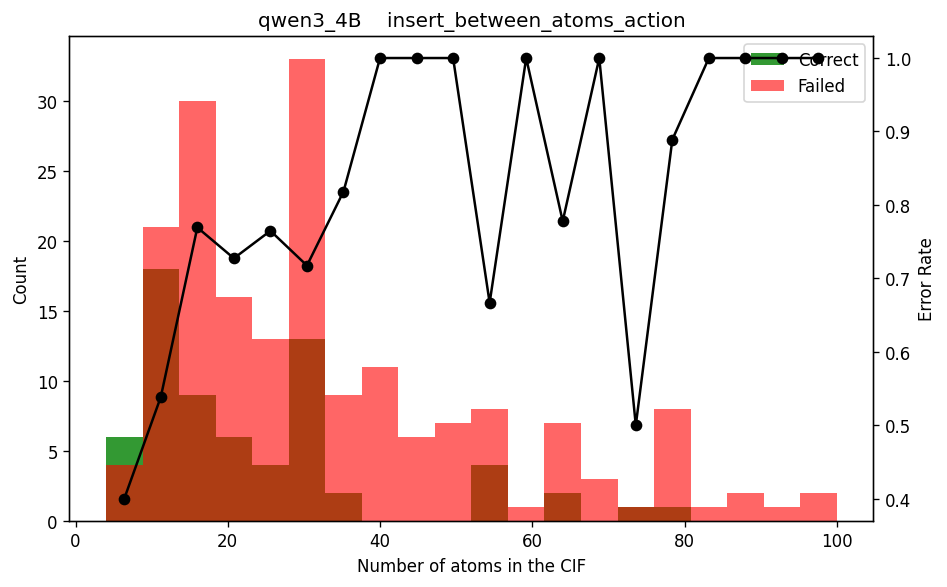

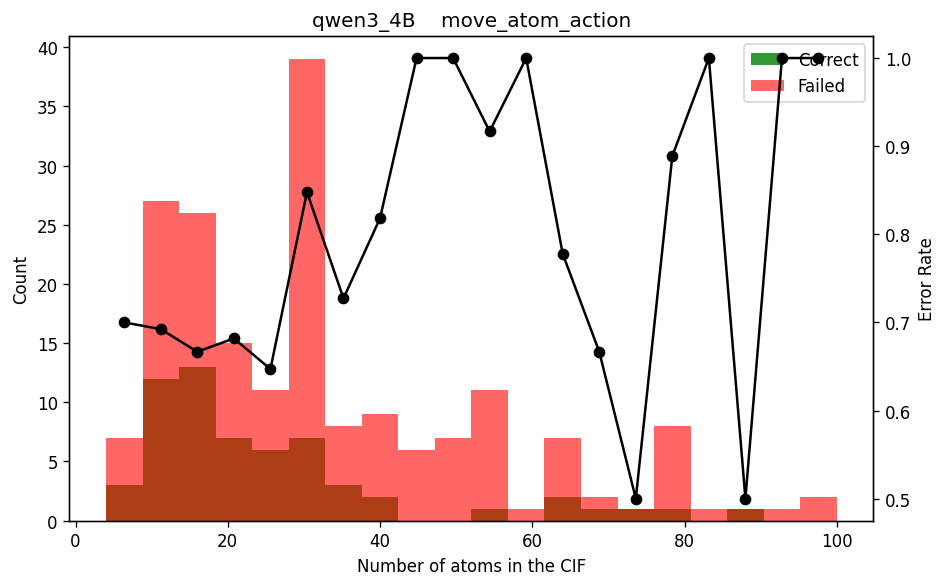

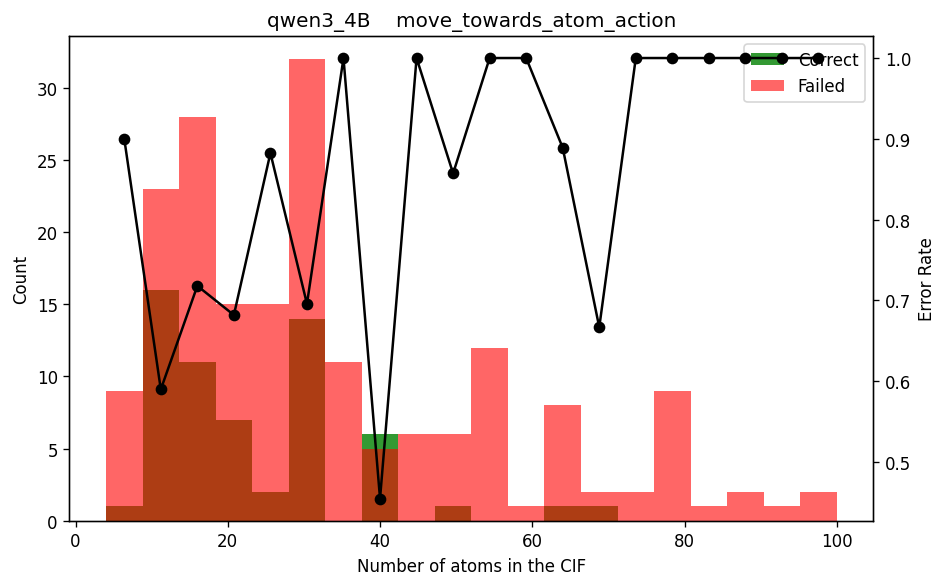

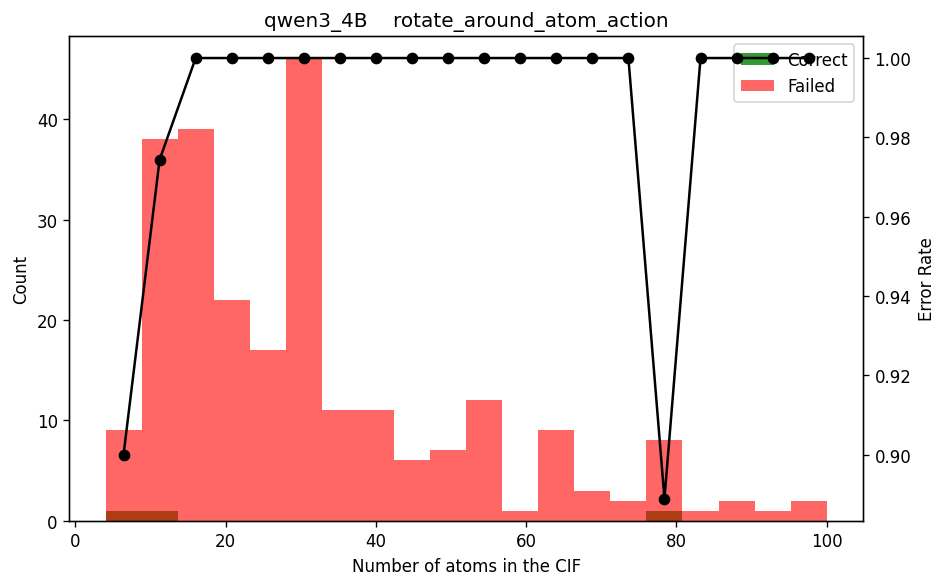

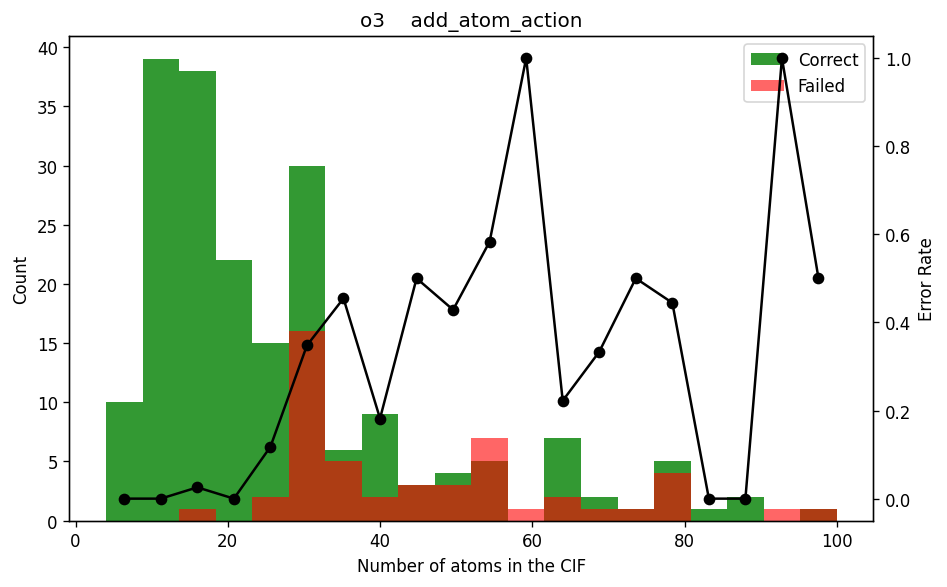

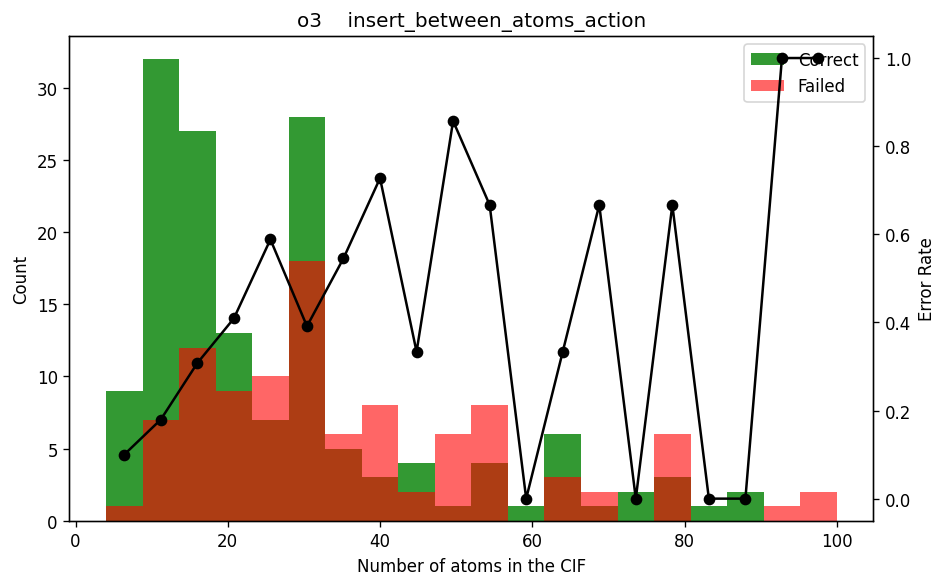

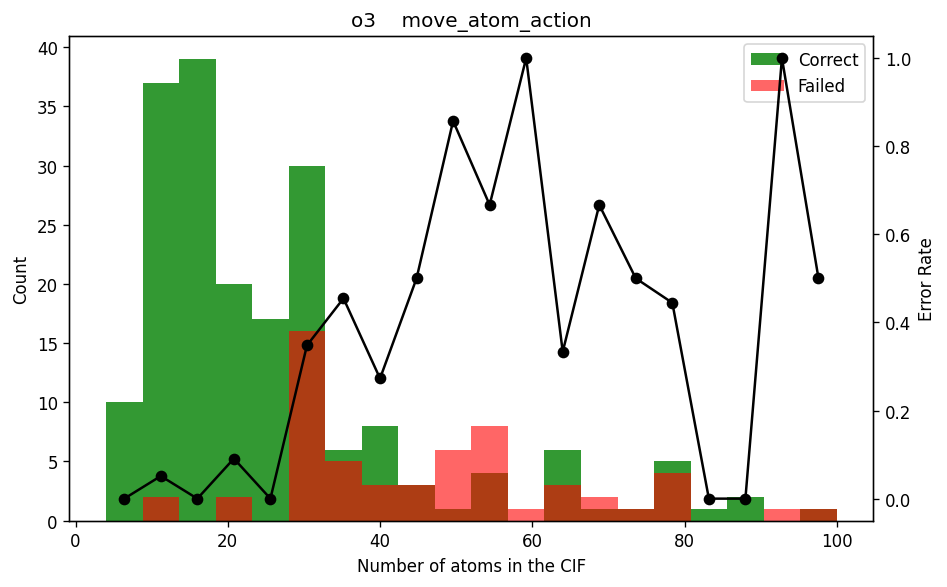

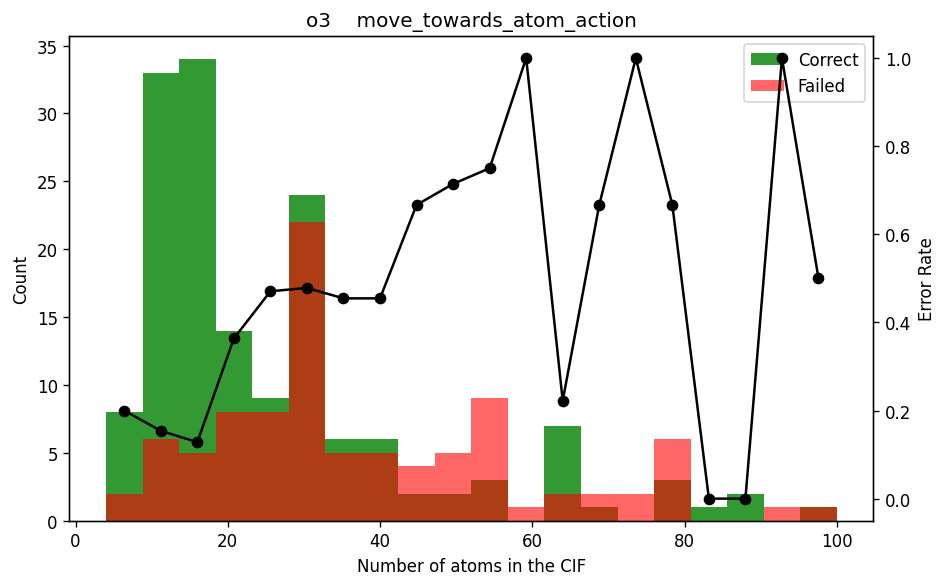

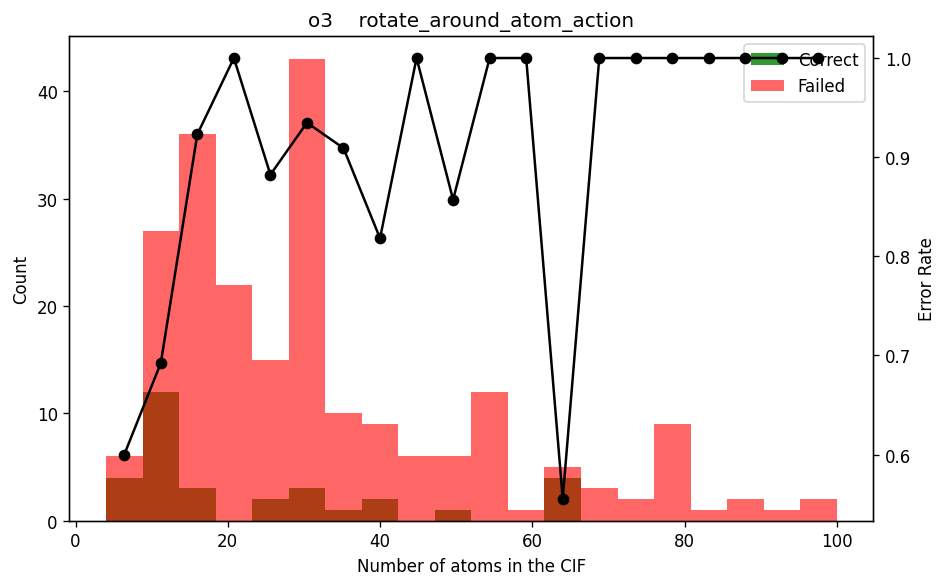

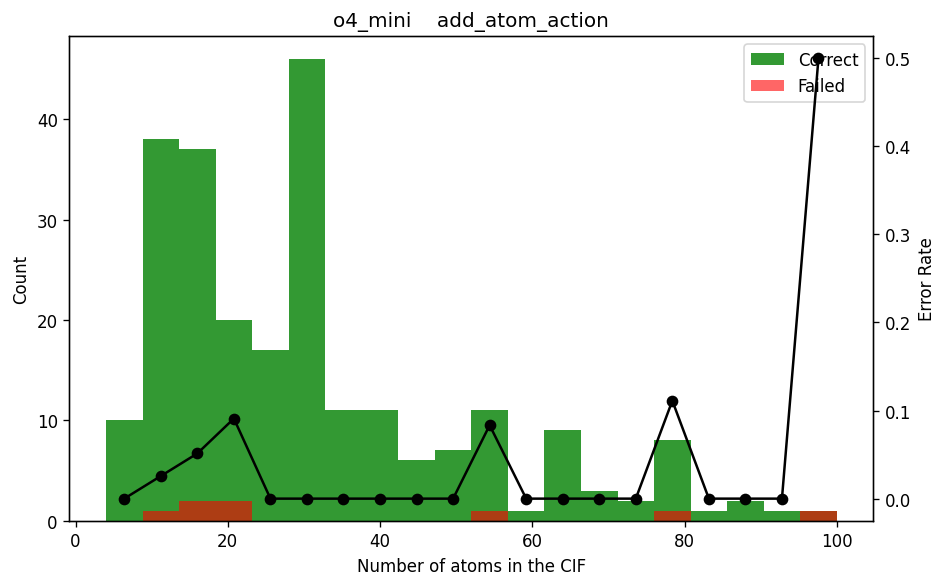

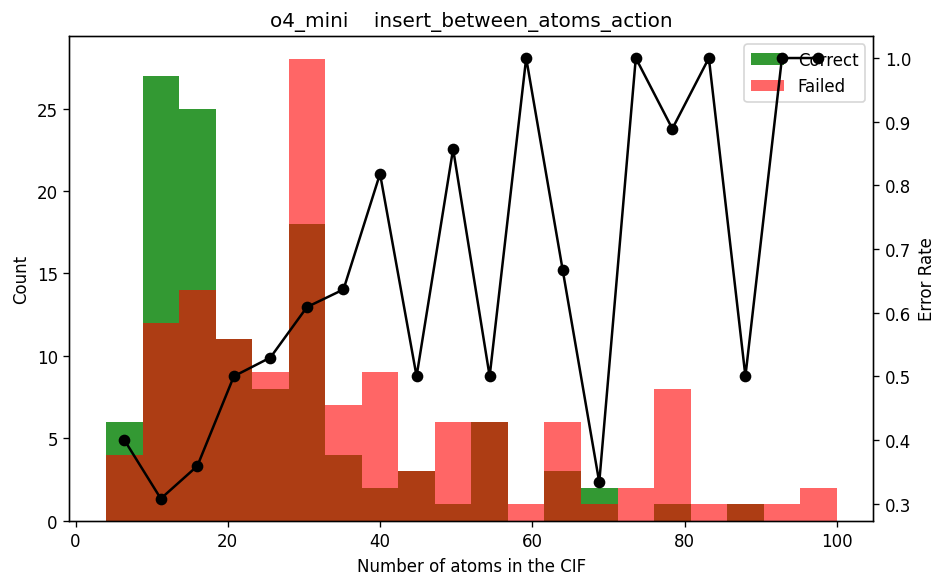

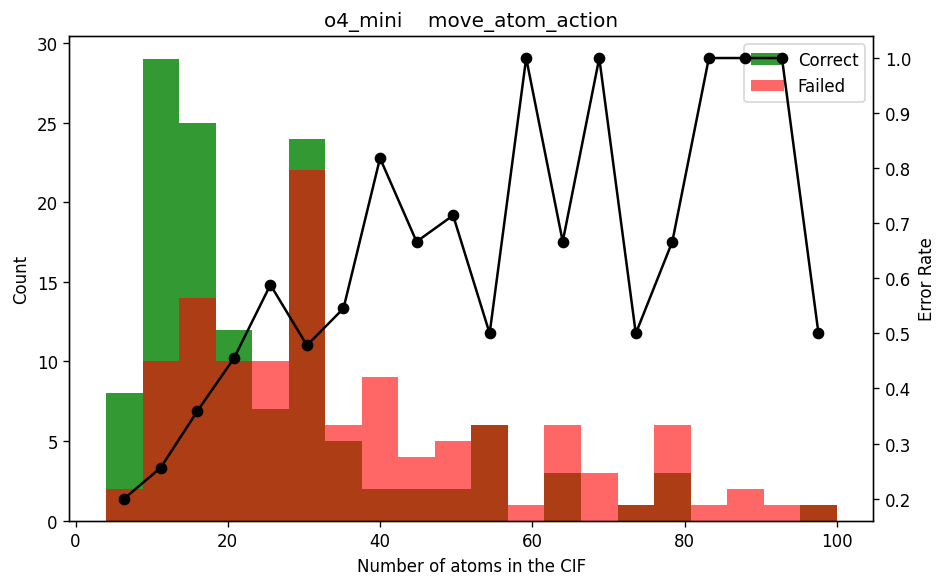

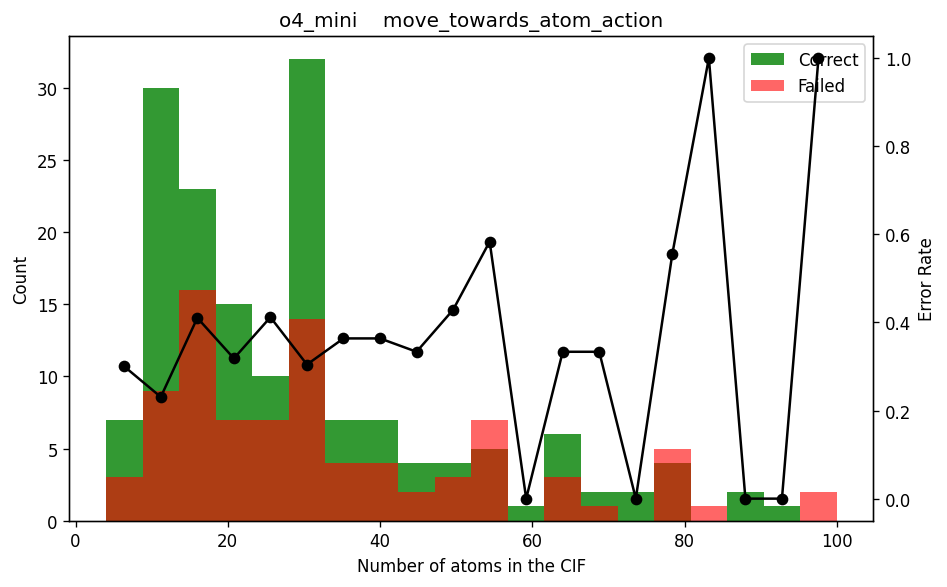

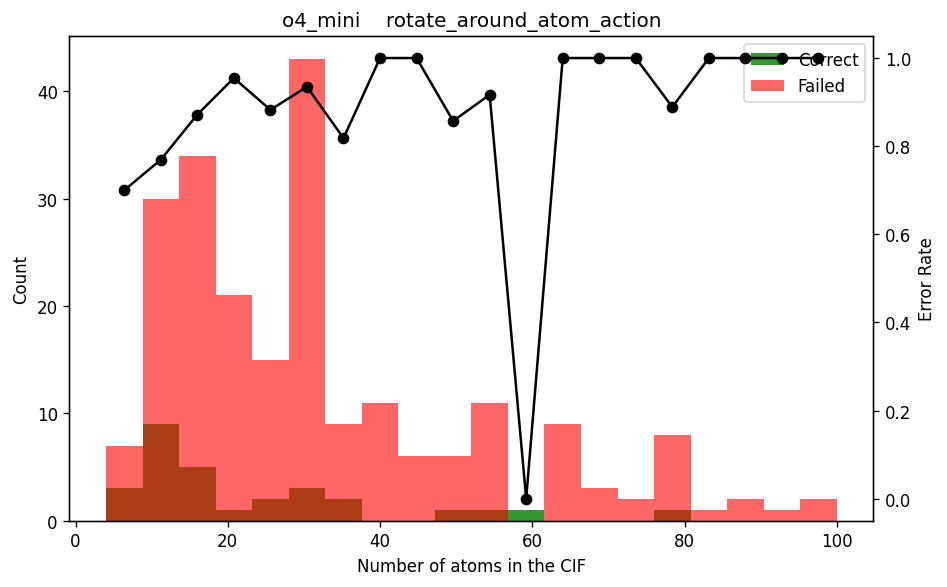

In [77]:
# get'em all
import os

for model_name in models:
    for action_name in actions:
        base_folder = f'../../results/AtomWorld/{model_name}/{action_name}'
        # Check for subdirectories
        if os.path.isdir(base_folder):
            # candidate subfolders (ignore 'logs' or anything irrelevant)
            candidates = [
                os.path.join(base_folder, d) for d in os.listdir(base_folder)
                if os.path.isdir(os.path.join(base_folder, d)) and d.lower() != "logs"
            ]

            if candidates:
                # pick newest by modification time
                result_folder = max(candidates, key=os.path.getmtime)
            else:
                # no subfolders, use base directly
                result_folder = base_folder
        else:
            continue

        # Now construct paths
        result_correct = os.path.join(result_folder, f'{action_name}_evaluation_results.csv')
        result_wrong   = os.path.join(result_folder, f'{action_name}_evaluation_wrongs.csv')

        try:
            result_correct = pd.read_csv(result_correct)
            result_wrong = pd.read_csv(result_wrong)
        except Exception as e:
            print(e)
            continue

        result_correct["num_site"] = result_correct["input_cif"].apply(
            lambda cif: load_cif_file_from_string(cif).num_sites
        )

        result_wrong["num_site"] = result_wrong["input_cif"].apply(
            lambda cif: load_cif_file_from_string(cif).num_sites
        )

        all_data = list(result_correct["num_site"]) + list(result_wrong["num_site"])
        bins = np.linspace(min(all_data), max(all_data), 21)  # 50 bins

        # Histogram counts
        counts_correct, _ = np.histogram(result_correct["num_site"], bins=bins)
        counts_wrong, _   = np.histogram(result_wrong["num_site"], bins=bins)

        # Error rate per bin (avoid division by zero)
        error_rate = np.zeros_like(counts_wrong, dtype=float)
        mask = (counts_correct + counts_wrong) > 0
        error_rate[mask] = counts_wrong[mask] / (counts_correct[mask] + counts_wrong[mask])

        # Bin centers
        bin_centers = 0.5 * (bins[:-1] + bins[1:])

        # --- Plot histogram ---
        plt.figure(figsize=(8, 5), dpi=120)
        plt.hist(result_correct["num_site"], bins=bins, color="green", alpha=0.8, label="Correct")
        plt.hist(result_wrong["num_site"], bins=bins, color="red", alpha=0.6, label="Failed")

        plt.xlabel("Number of atoms in the CIF")
        plt.ylabel("Count")
        plt.title(f"{model_name}    {action_name}")
        plt.legend()

        # --- Plot error rate (second y-axis) ---
        ax2 = plt.gca().twinx()
        ax2.plot(bin_centers, error_rate, color="black", marker="o", linestyle="-", label="Error Rate")
        ax2.set_ylabel("Error Rate")

        plt.tight_layout()
        plt.savefig(f"{model_name}-{action_name}.png", dpi=300)

        